# **Libraries**

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, TimeDistributed, Concatenate
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from  tensorflow.keras.optimizers import Adam
from keras.utils import custom_object_scope
import tensorflow as tf

# **Constants**

In [3]:
PATH_TRAINING_A = '../data/julius/siamese_real_sequence_train_a.npy'
PATH_TRAINING_B = '../data/julius/siamese_real_sequence_train_b.npy'
CHECKPOINT_CALLBACK = '../checkpoints/siamese/weights/weights_2.weights.h5'
PATH_SAVE_MODEL_1 = ''
PATH_SAVE_MODEL_2 = ''


# **Functions**

In [4]:
def predict_reconstructed_sequences(network, sequence_a, sequence_b):
    combined_prediction = network.predict([sequence_a, sequence_b])
    reconstructed_sequence_a = combined_prediction[:, :80]
    reconstructed_sequence_b = combined_prediction[:, 80:]
    return reconstructed_sequence_a, reconstructed_sequence_b


In [5]:
def plot_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [6]:
def cut_off_padding(lines, n_points):
  new_lines = []
  for line in lines:
    new_lines.append(line[n_points:-n_points])

  return np.array(new_lines)


In [7]:
def plot_lines(lines_a_nopad, lines_b_nopad, n, a, b, title):
  plt.plot(lines_a_nopad[n, :, 0], lines_a_nopad[n, :, 1], linestyle='--', color='red', label='Line A')
  plt.plot(a[n, :, 0], a[n, :, 1], color='red', label='Line A reconstructed')
  plt.plot(lines_b_nopad[n, :, 0], lines_b_nopad[n, :, 1], linestyle='--', color='blue', label='Line B')
  plt.plot(b[n, :, 0], b[n, :, 1], color='blue', label='Line B reconstructed')
  plt.scatter(b[n, :, 0], b[n, :, 1], color='blue', s=4)
  plt.legend()
  plt.title(title)
  plt.show()

In [8]:
def plot_compare_models(pred1_a, pred1_b, pred2_a, pred2_b, train_data_a, train_data_b, indices, path):
    width = 5
    height = 3
    fig, axs = plt.subplots(nrows=len(indices), ncols=2, figsize=(width, height*len(indices)))

    for i, idx in enumerate(indices):
        axs[i, 0].plot(train_data_a[idx][:,0], train_data_a[idx][:,1], color='red', linestyle='--', label='Ground Truth A')
        axs[i, 0].plot(pred1_a[idx][:,0], pred1_a[idx][:,1], color='red', label='Prediction A')
        axs[i, 0].plot(train_data_b[idx][:,0], train_data_b[idx][:,1], color='blue', linestyle='--',  label='Ground Truth B')
        axs[i, 0].plot(pred1_b[idx][:,0], pred1_b[idx][:,1], color='blue', label='Prediction B')
        axs[i, 0].set_xticks([])
        axs[i, 0].set_yticks([])
        axs[i, 0].tick_params(axis='both', which='both', length=0)
        axs[i, 0].axis('equal')

        axs[i, 1].plot(train_data_a[idx][:,0], train_data_a[idx][:,1], color='red', linestyle='--', label='Ground Truth A')
        axs[i, 1].plot(pred2_a[idx][:,0], pred2_a[idx][:,1], color='red', label='Prediction A')
        axs[i, 1].plot(train_data_b[idx][:,0], train_data_b[idx][:,1], color='blue', linestyle='--',  label='Ground Truth B')
        axs[i, 1].plot(pred2_b[idx][:,0], pred2_b[idx][:,1], color='blue', label='Prediction B')
        axs[i, 1].set_xticks([])
        axs[i, 1].set_yticks([])
        axs[i, 1].tick_params(axis='both', which='both', length=0)
        axs[i, 1].axis('equal')

    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)

    #plt.savefig(path, dpi=300, bbox_inches='tight')

    plt.show()


# **Model**

In [9]:
checkpoint_callback = ModelCheckpoint(
    filepath=CHECKPOINT_CALLBACK,
    monitor="loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)



# def perp_distance(args):
#     point_a1, point_a2, point_b = args

#     lvs = point_a1
#     lve = point_a2
#     dvc = lve - lvs
#     pvc = point_b

#     # Neu hinzugefügt: Behandlung des Falls, wenn lvs und lve gleich sind.
#     if tf.reduce_all(tf.equal(lvs, lve)):
#         return tf.norm(pvc - lvs)

#     tvc = lvs - pvc
#     tm0 = tvc * dvc
#     tm1 = dvc * dvc

#     lbd = -tf.reduce_sum(tm0) / (tf.reduce_sum(tm1) + tf.keras.backend.epsilon())
#     nvc = lvs + lbd * dvc

#     dist_inside = tf.norm(nvc - pvc)
#     dist_start = tf.norm(nvc - lvs)
#     dist_end = tf.norm(nvc - lve)

#     condition_inside = tf.logical_and(tf.greater(lbd, 0), tf.less(lbd, 1))
#     condition_start = tf.less_equal(lbd, 0)

#     dist = tf.where(condition_inside, dist_inside,
#                     tf.where(condition_start, dist_start, dist_end))

#     return dist

def perp_distance(args):
    point_a1, point_a2, point_b = args
    lvs = point_a1 #Start des Richtungsvektors Line Segment A
    lve = point_a2 #Ende des Richtungsvektors Line Segment A
    dvc = lve - lvs #Richtungsvektor
    pvc = point_b #Punkt, zu dem Abstand berechnet werden soll

    #If the segment is a single point (start = end), simply compute the Euclidean distance from pvc to lvs
    def case_equal():
        return tf.norm(pvc - lvs)

    def case_unequal():
        tvc = lvs - pvc #vector from point to segment start.
        tm0 = tvc * dvc #dot products used to compute projection scalar lbd
        tm1 = dvc * dvc
        lbd = -tf.reduce_sum(tm0) / (tf.reduce_sum(tm1) + tf.keras.backend.epsilon()) #tells how far along the line the projection falls, small epsilon added to avoid division by zero
        nvc = lvs + lbd * dvc #nearest point on the line segment (can be outside the actual segment).
        dist_inside = tf.norm(nvc - pvc)
        dist_start = tf.norm(nvc - lvs)
        dist_end = tf.norm(nvc - lve)
        condition_inside = tf.logical_and(tf.greater(lbd, 0), tf.less(lbd, 1)) #condition_inside: projection inside the segment.
        condition_start = tf.less_equal(lbd, 0) #condition_start: projection before start (otherwise after end).
        return tf.where(condition_inside, dist_inside, tf.where(condition_start, dist_start, dist_end))

    condition = tf.reduce_all(tf.equal(lvs, lve))

    #If inside, use the perpendicular distance, Otherwise, use distance to nearest endpoint.
    return tf.cond(condition, case_equal, case_unequal)

#NEW
# def perp_distance(args):

#     point_a1, point_a2, point_b = args
#     # Direction vector of the segment
#     v = point_a2 - point_a1                     # (..., 2)
#     # Vector from A1 to the query point
#     w = point_b  - point_a1                     # (..., 2)

#     # Squared length of the segment ‖v‖²  (add ε for numerical safety)
#     vv = tf.reduce_sum(tf.square(v), axis=-1, keepdims=True) + tf.keras.backend.epsilon()

#     # Projection scalar t = (w·v) / (‖v‖²)  — clip to [0,1] to stay on the *segment*
#     t = tf.reduce_sum(w * v, axis=-1, keepdims=True) / vv
#     t_clipped = tf.clip_by_value(t, 0.0, 1.0)  # (..., 1)

#     # Nearest point on the segment to point_b
#     nearest = point_a1 + t_clipped * v         # (..., 2)

#     # Euclidean distance ‖point_b − nearest‖
#     return tf.norm(point_b - nearest, axis=-1) # (...,)


def displacement_loss(y_pred_b, y_true_a):
    min_distances = []
    for point_b in tf.unstack(y_pred_b, axis=1):
        dists = tf.map_fn(perp_distance, (y_true_a[:-1], y_true_a[1:], point_b), dtype=tf.float32)
        min_dist = tf.reduce_min(dists)
        min_distances.append(min_dist)
    return tf.reduce_mean(min_distances)


def combined_loss(y_true_a, y_pred_a, y_pred_b, y_true_b, alpha):
    mse_loss_a = tf.reduce_mean(tf.keras.losses.MSE(y_true_a, y_pred_a))
    mse_loss_b = tf.reduce_mean(tf.keras.losses.MSE(y_true_b, y_pred_b))
    disp_loss = displacement_loss(y_pred_b, y_true_a)
    # tf.print('mseloss:' ,mse_loss_a+mse_loss_b, 'neg disp:' ,- (alpha * disp_loss))
    return mse_loss_a + mse_loss_b - (alpha * disp_loss)



def siamese_loss_wrapper(alpha):
    def siamese_loss(y_true, y_pred):
        y_true_a, y_true_b = y_true[:, :80], y_true[:, 80:]
        y_pred_a, y_pred_b = y_pred[:, :80], y_pred[:, 80:]
        return combined_loss(y_true_a, y_pred_a, y_pred_b, y_true_b, alpha)
    return siamese_loss


# def parabolaScaledShift(indist, dist_opt, exp):
#     scale = 1. / dist_opt
#     trafodist = -1 + indist * scale
#     trafodist = tf.where(trafodist > 0, 0., trafodist)
#     return trafodist ** exp

# def linearScaledShift(mseX, mseY, satur):
#     mseD = tf.sqrt(mseX ** 2 + mseY ** 2)
#     return tf.where(mseD <= satur, mseD / satur, 1.)

# def combine2Costs(costA, costB, weightA, weightB):
#     weightT = weightA + weightB
#     weightA = weightA / weightT
#     weightB = weightB / weightT
#     return weightA * costA + weightB * costB

# def combined_loss(y_true_a, y_pred_a, y_pred_b, y_true_b, dist_opt, exp, satur, weightA, weightB):
#     mse_loss_a = tf.reduce_mean(tf.keras.losses.MSE(y_true_a, y_pred_a))
#     mse_loss_b = tf.reduce_mean(tf.keras.losses.MSE(y_true_b, y_pred_b))
#     tf.print('mse_losses:' , mse_loss_a, mse_loss_b)
#     mse_cost = linearScaledShift(mse_loss_a, mse_loss_b, satur)
#     tf.print('lss:' , mse_cost)

#     disp_loss = displacement_loss(y_true_a, y_pred_b)
#     disp_cost = parabolaScaledShift(disp_loss, dist_opt, exp)
#     tf.print('disp:' , disp_loss, disp_cost)
#     return combine2Costs(mse_cost, disp_cost, weightA, weightB)

# def siamese_loss_wrapper(dist_opt, exp, satur, weightA, weightB):
#     def siamese_loss(y_true, y_pred):
#         y_true_a, y_true_b = y_true[:, :80], y_true[:, 80:]
#         y_pred_a, y_pred_b = y_pred[:, :80], y_pred[:, 80:]
#         return combined_loss(y_true_a, y_pred_a, y_pred_b, y_true_b, dist_opt, exp, satur, weightA, weightB)
#     return siamese_loss


def create_autoencoder(input_shape, prefix):
    # Define Encoder
    inputs = Input(shape=input_shape)
    encoder_bi_lstm1 = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    encoder_bi_lstm2 = Bidirectional(LSTM(64, return_sequences=True))(encoder_bi_lstm1)
    encoder_bi_lstm3 = Bidirectional(LSTM(32, return_sequences=True, return_state=True))
    encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_bi_lstm3(encoder_bi_lstm2)
    state_h = Concatenate()([forward_h, backward_h])
    state_c = Concatenate()([forward_c, backward_c])
    encoder_states = [state_h, state_c]

    # Define Decoder
    # Verwenden Sie den Zustand des Encoders als Eingabe für den Decoder
    forward_decoder_lstm = LSTM(32, return_sequences=True)
    backward_decoder_lstm = LSTM(32, return_sequences=True, go_backwards=True)
    forward_decoder_outputs = forward_decoder_lstm(encoder_outputs, initial_state=[forward_h, forward_c])
    backward_decoder_outputs = backward_decoder_lstm(encoder_outputs, initial_state=[backward_h, backward_c])

    # Combine Forward and Backward LSTM
    decoder_outputs = Concatenate()([forward_decoder_outputs, backward_decoder_outputs])
    decoder_bi_lstm2 = Bidirectional(LSTM(64, return_sequences=True))(decoder_outputs)
    decoder_bi_lstm3 = Bidirectional(LSTM(128, return_sequences=True))(decoder_bi_lstm2)

    decoder_dense = TimeDistributed(Dense(2, activation='linear'))
    decoder_outputs = decoder_dense(decoder_bi_lstm3)
    autoencoder = Model(inputs, decoder_outputs)

    return autoencoder


input_shape = (80, 2)
autoencoder_a = create_autoencoder(input_shape, 'A')
autoencoder_b = create_autoencoder(input_shape, 'B')

input_sequence_a = Input(shape=input_shape)
input_sequence_b = Input(shape=input_shape)

reconstructed_sequence_a = autoencoder_a(input_sequence_a)
reconstructed_sequence_b = autoencoder_b(input_sequence_b)

siamese_autoencoder = Model([input_sequence_a, input_sequence_b], Concatenate(axis=1)([reconstructed_sequence_a, reconstructed_sequence_b]))

2025-11-12 13:17:58.099564: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-12 13:17:58.099616: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-12 13:17:58.099622: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-12 13:17:58.099664: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-12 13:17:58.099679: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
lines_a = np.load(PATH_TRAINING_A)[:10]
lines_b = np.load(PATH_TRAINING_B)[:10]

In [11]:
lines_a

array([[[2.16275591e-01, 8.44486112e-03],
        [2.16541785e-01, 8.21702119e-03],
        [2.16807978e-01, 7.98918126e-03],
        ...,
        [2.38090428e-01, 1.15432050e-03],
        [2.38383823e-01, 1.22200357e-03],
        [2.38677219e-01, 1.28968663e-03]],

       [[2.33102980e-01, 0.00000000e+00],
        [2.33396345e-01, 6.80951076e-05],
        [2.33689710e-01, 1.36190215e-04],
        ...,
        [2.52551434e-01, 1.71402736e-02],
        [2.52777383e-01, 1.74771643e-02],
        [2.53003333e-01, 1.78140550e-02]],

       [[2.48592962e-01, 1.16755730e-02],
        [2.48831180e-01, 1.19850712e-02],
        [2.49069397e-01, 1.22945694e-02],
        ...,
        [2.65431990e-01, 3.74953923e-02],
        [2.65563928e-01, 3.79624168e-02],
        [2.65695866e-01, 3.84294413e-02]],

       ...,

       [[1.85084036e-01, 2.35979311e-02],
        [1.84792718e-01, 2.35065087e-02],
        [1.84501400e-01, 2.34150862e-02],
        ...,
        [1.69718743e-01, 1.14378717e-02],
     

In [29]:
siamese_autoencoder.save(f'../checkpoints/siamese/model/model_julius.keras')

In [30]:
siamese_autoencoder.compile(optimizer='adam', loss=siamese_loss_wrapper(0.0006))
lines_combined = np.concatenate([lines_a, lines_b], axis=1)

history = siamese_autoencoder.fit([lines_a, lines_b], lines_combined, epochs=1500, batch_size=32, callbacks=[checkpoint_callback])

Epoch 1/1500


2025-11-11 22:28:37.618236: W tensorflow/core/common_runtime/type_inference.cc:339] Type inference failed. This indicates an invalid graph that escaped type checking. Error message: INVALID_ARGUMENT: expected compatible input types, but input 1:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_BOOL
    }
  }
}
 is neither a subtype nor a supertype of the combined inputs preceding it:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_FLOAT
    }
  }
}

	for Tuple type infernce function 0
	while inferring type of node 'StatefulPartitionedCall/compile_loss/siamese_loss/map/while/body/_238/compile_loss/siamese_loss/map/while/cond/output/_31927'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183s/step - loss: 0.0405
Epoch 1: loss improved from None to 0.04047, saving model to ../checkpoints/siamese/weights/weights_2.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 184s 184s/step - loss: 0.0405
Epoch 2/1500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99s/step - loss: 0.0209
Epoch 2: loss improved from 0.04047 to 0.02089, saving model to ../checkpoints/siamese/weights/weights_2.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 99s 99s/step - loss: 0.0209
Epoch 3/1500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64s/step - loss: 0.0060
Epoch 3: loss improved from 0.02089 to 0.00596, saving model to ../checkpoints/siamese/weights/weights_2.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 65s 65s/step - loss: 0.0060
Epoch 4/1500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44s/step - loss: 0.0173
Epoch 4: loss did not improve from 0.00596
1/1 ━━━━━━━━━━━━━━━━━━━━ 44s 44s/step - loss: 0.0173
Epoch 5/1500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37s/step - loss: 0.0093
Epoch 5: loss did not improve from 0.00596
1/1 ━━━━━━━━━━━━━━━━━━━━ 37s 37s/step - lo

In [1]:
siamese_autoencoder.load_weights(filepath=CHECKPOINT_CALLBACK)

NameError: name 'siamese_autoencoder' is not defined

# **Post-Training**

## Save / Load Models

In [ ]:
# siamese_autoencoder.save('/content/drive/MyDrive/models/displace_real_a0_00055_10k_epochs.hdf5')

In [ ]:
# siamese_loss = siamese_loss_wrapper(0.00055)

# with custom_object_scope({'displacement_loss': displacement_loss, 'combined_loss': combined_loss, 'siamese_loss': siamese_loss}):
#   siamese_8 = tf.keras.models.load_model('/content/drive/MyDrive/models/displace_real_a0_00055_10k_epochs.hdf5')
#   siamese_0_65 = tf.keras.models.load_model('/content/drive/MyDrive/models/displace_real_a0_0007_10k_epochs.hdf5')

In [31]:
pred_siamese_a, pred_siamese_b = predict_reconstructed_sequences(siamese_autoencoder, lines_a, lines_b)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [32]:
pred_siamese_a = cut_off_padding(pred_siamese_a, 10)
pred_siamese_b = cut_off_padding(pred_siamese_b, 10)
lines_a_nopad = cut_off_padding(lines_a, 10)
lines_b_nopad = cut_off_padding(lines_b, 10)

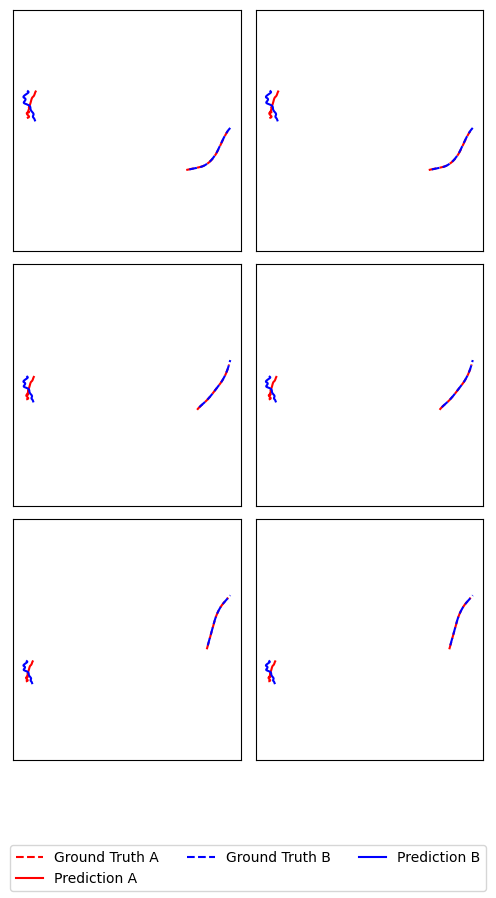

In [ ]:
plot_compare_models(pred_siamese_a, pred_siamese_b, pred_siamese_a, pred_siamese_b, lines_a_nopad, lines_b_nopad, [1,2,3], '/content/drive/MyDrive/abb/siamese.png')